# Hotel Booking Data - Statistics

Data source: [Hotel Booking Demand (Kaggle)](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand/data)

## 1. Setup and Data Loading

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utils import load_hotel_data, DATA_DIR

# Theme: hotel/booking — teal primary, warm neutrals
THEME = {
    "primary": "#0d9488",
    "secondary": "#64748b",
    "accent": "#f59e0b",
    "bg": "#f8fafc",
    "palette": ["#0d9488", "#64748b", "#f59e0b", "#06b6d4", "#8b5cf6"],
}
sns.set_theme(style="whitegrid", palette=THEME["palette"], font_scale=1.1)
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = THEME["bg"]

%matplotlib inline

In [13]:
df = load_hotel_data()
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2. Basic Dataset Overview

In [14]:
print(f"Shape: {df.shape}")
print(f"Columns ({len(df.columns)}):")
print(df.columns.tolist())
print(f"Data types:")
df.dtypes

Shape: (119390, 32)
Columns (32):
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']
Data types:


hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

## 3. Missing Values

In [15]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    display(pd.DataFrame({"missing_count": missing, "pct": (missing / len(df) * 100).round(2)}))

,missing_count,pct
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


## 4. Target Variable: is_canceled

In [16]:
print(df["is_canceled"].value_counts())
print(f"Cancel rate: {df['is_canceled'].mean():.2%}")

is_canceled
0    75166
1    44224
Name: count, dtype: int64
Cancel rate: 37.04%


## 5. Summary Statistics

In [17]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


## 6. Categorical Features - Value Counts

In [18]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
for col in cat_cols[:10]:
    print(f"\n{col}:")
    print(df[col].value_counts().head())


hotel:
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

arrival_date_month:
arrival_date_month
August     13877
July       12661
May        11791
October    11160
April      11089
Name: count, dtype: int64

meal:
meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64

country:
country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
Name: count, dtype: int64

market_segment:
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Name: count, dtype: int64

distribution_channel:
distribution_channel
TA/TO        97870
Direct       14645
Corporate     6677
GDS            193
Undefined        5
Name: count, dtype: int64

reserved_room_type:
reserved_room_type
A    85994
D    19201
E     6535
F     2897
G     2094
Name: count, dtype: int64

assigned_room_type:
assigned_room_type
A    74053
D    25322
E 

## 7. Hotel Type & Seasonal Breakdown

By hotel type:


,count,mean
hotel,,
City Hotel,79330,0.417270
Resort Hotel,40060,0.277634



Cancel rate by month:


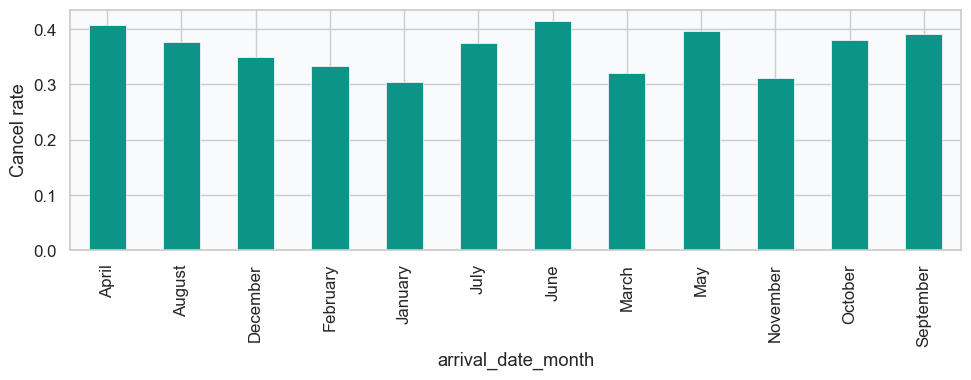

In [19]:
if "hotel" in df.columns:
    print("By hotel type:")
    display(df.groupby("hotel")["is_canceled"].agg(["count", "mean"]))
if "arrival_date_month" in df.columns:
    print("\nCancel rate by month:")
    ax = df.groupby("arrival_date_month")["is_canceled"].mean().plot(
        kind="bar", figsize=(10, 4), color=THEME["primary"], edgecolor="white", linewidth=0.5
    )
    ax.set_ylabel("Cancel rate")
    plt.tight_layout()
    plt.show()

# Put in report

In [20]:
summary = {
    "Total observations": len(df),
    "Number of features": df.shape[1],
    "Cancellation rate": df["is_canceled"].mean(),
}
pd.DataFrame.from_dict(summary, orient="index", columns=["Value"])

,Value
Total observations,119390.000000
Number of features,32.000000
Cancellation rate,0.370416


<Axes: xlabel='is_canceled', ylabel='count'>

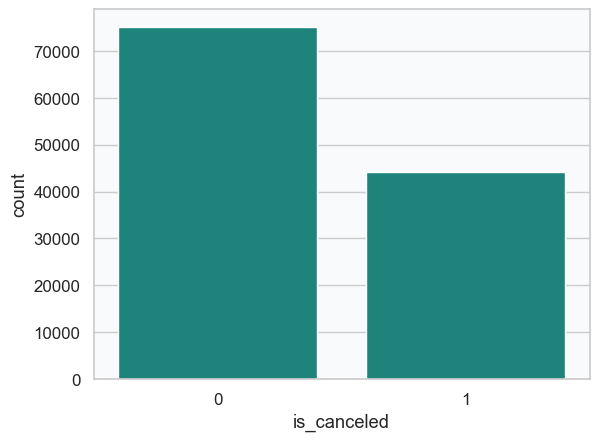

In [21]:
sns.countplot(x="is_canceled", data=df)

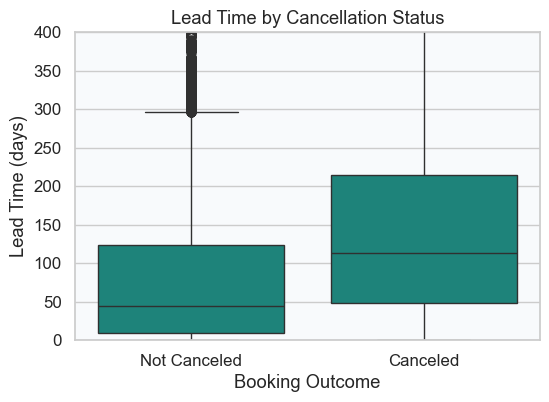

In [27]:
plt.figure(figsize=(6,4))

sns.boxplot(x="is_canceled", y="lead_time", data=df)

plt.xticks([0,1], ["Not Canceled", "Canceled"])
plt.xlabel("Booking Outcome")
plt.ylabel("Lead Time (days)")
plt.title("Lead Time by Cancellation Status")

plt.ylim(0,400)

plt.show()

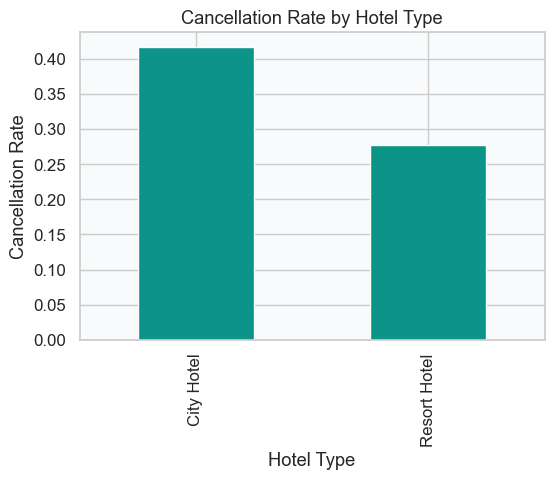

In [28]:
hotel_cancel = df.groupby("hotel")["is_canceled"].mean()

hotel_cancel.plot(kind="bar", figsize=(6,4))

plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Rate")
plt.title("Cancellation Rate by Hotel Type")
plt.xticks(rotation=0)

plt.show()